# 4.1.1 从三个平衡进入多稳态

## 学习目标与先修知识

能用一维流向和局部导数（derivative）区分平衡（equilibrium）的稳定性，推导开关模型（model）的解析解（analytical solution），并说明精确停在平衡与抵抗扰动的区别。

先修：第 3.4 章的平衡与线性化（linearization）；导数、指数函数（exponential function）和变量替换。 [复习上一节](../../03-多变量相互作用/04-多变量变化与局部线性化/02-线性化能够走多远.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

细胞调控活动可能在低、高两种状态（state）间切换。同样的外部条件下，为什么过去受到的刺激仍可能影响当前状态？用一个有两个吸引状态的理想开关检验这一可能机制。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
points=np.array([-1.5,-1.,-.5,0.,.5,1.,1.5])
rates=points-points**3
display(Markdown(show_table(['x','x−x³','局部导数 1−3x²'],zip(points,rates,1-3*points**2))))

| x | x−x³ | 局部导数 1−3x² |
| --- | --- | --- |
| -1.5 | 1.875 | -5.75 |
| -1 | 0 | -2 |
| -0.5 | -0.375 | 0.25 |
| 0 | 0 | 1 |
| 0.5 | 0.375 | 0.25 |
| 1 | 0 | -2 |
| 1.5 | -1.875 | -5.75 |

## 模型假设

以 x=(A−Aref)/Ascale 表示相对参考活动的无量纲（dimensionless）偏差，τ=t/t0 为无量纲时间，t0>0。负 x 表示低于参考值，不是负浓度（concentration）。本篇代码以 t 表示 τ，所有方程系数均在这个缩放下给出。

模型为 dx/dτ=x−x³：线性项推动增长，三次项在幅度较大时起抑制作用。两项参数（parameter）经缩放取为 1；忽略噪声、空间差异和外部时间变化。

## 数学解释与推导

平衡要求 f(x*)=0，故 x*=−1、0、1。附近的小偏差 δ 满足 δ′≈f′(x*)δ，其中 f′=1−3x²：在 ±1 得 −2，扰动衰减；在 0 得 1，扰动增长。因此同一方程有两个局部渐近稳定（local asymptotic stability）平衡，称为双稳态（bistability），多稳态（multistability）是存在多个吸引状态的更一般情形。

不只看导数，还画出**相线（phase line）**：在 −1 左侧 f>0，在 (−1,0) 内 f<0，在 (0,1) 内 f>0，在 1 右侧 f<0。箭头分别指向 −1 与 1，零点把去向分开。吸引域（basin of attraction）是最终趋向某吸引状态的初值（initial condition）集合；本例 −1 的吸引域为 (−∞,0)，1 的吸引域为 (0,∞)。精确 x0=0 永久为 0，但任意小的正负扰动都会离开，所以“保持在平衡”不是稳定性的定义。

还可以独立求解。非零轨迹（trajectory）令 s=x²，则
$$s'=2x(x-x^3)=2s(1-s).$$
令 w=1/s，则 w′=−2w+2，所以 w=1+(w0−1)e^(−2τ)。恢复符号后得到
$$x(\tau)=\frac{x_0}{\sqrt{x_0^2+(1-x_0^2)e^{-2\tau}}}.$$
对 τ≥0，分母平方可写成 x0²(1−e^(−2τ))+e^(−2τ)>0，所以有限初值（initial condition）不会在该式中失效。零初值单独返回零。这一解析式保留符号，并分别趋向 ±1。

一维光滑自治流不能产生非平凡周期轨道：相邻平衡之间 f 的符号固定，解只能沿一个方向运动；要掉头必须到达 f=0，而解的唯一性使到达平衡的解保持在那里。之后的一维**离散映射**不受这段连续流论证限制。

若 f′=0，只能说线性判据未决。例如 −x³ 从两侧指向零，x³ 却从两侧远离，不能把“零导数”自动读成稳定或不稳定。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def switch_exact(initial,times):
    result=[]
    for t in times:
        if initial==0:
            result.append(0.0)
        else:
            square=initial*initial
            result.append(initial/math.sqrt(square+(1-square)*math.exp(-2*t)))
    return result

## 对照实验

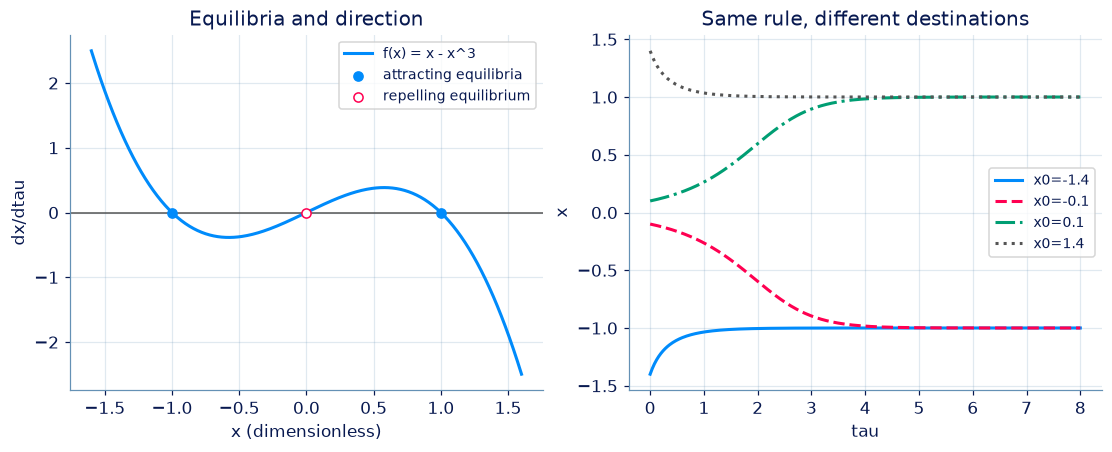

In [4]:
times=np.linspace(0,8,401)
fig,axes=plt.subplots(1,2,figsize=(10,4))
grid=np.linspace(-1.6,1.6,321)
axes[0].plot(grid,grid-grid**3,color=BLUE,label='f(x) = x - x^3')
axes[0].axhline(0,color=GRAY,lw=1)
axes[0].scatter([-1,1],[0,0],color=BLUE,zorder=4,label='attracting equilibria')
axes[0].scatter([0],[0],facecolors='white',edgecolors=PINK,zorder=4,label='repelling equilibrium')
for x0,color,style in [(-1.4,BLUE,'-'),(-.1,PINK,'--'),(.1,GREEN,'-.'),(1.4,GRAY,':')]:
    axes[1].plot(times,switch_exact(x0,times),color=color,ls=style,label=f'x0={x0}')
axes[0].set(xlabel='x (dimensionless)',ylabel='dx/dtau',title='Equilibria and direction')
axes[1].set(xlabel='tau',ylabel='x',title='Same rule, different destinations')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

左图实心标记的两处零点吸引邻近状态，空心的零点排斥；右图四条轨迹（trajectory）按初值符号分开。曲线颜色对应不同初值而非好坏状态。靠近零的初值先缓慢离开，有限时间内还没靠近 ±1 不等于出现了第三个稳定状态。

这是活动偏差的机制类比。要主张某种真实细胞存在双稳态，还需要测量、参数识别和可区分实验；形状相似本身不够。

### 独立核对

把解析式代回原方程，用中心差分（central difference）检查导数残差（residual）；这比只比较两个调用同一公式的结果更能发现符号错误。

In [5]:
assert switch_exact(0,[0,1,8])==[0.,0.,0.]
for x0 in [-2,-1,-.1,.1,1,2]:
    assert abs(switch_exact(x0,[0])[0]-x0)<1e-14
    t,epsilon=1.,1e-5
    left,center,right=switch_exact(x0,[t-epsilon,t,t+epsilon])
    residual=(right-left)/(2*epsilon)-(center-center**3)
    assert abs(residual)<1e-8
print('初值、零解与原方程残差均一致。')

初值、零解与原方程残差均一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-01-多稳态与吸引域/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：三个不动点具有相同性质吗

理想开关 x′=x−x³ 中，x 是无量纲（dimensionless）偏差。哪些说法成立？

- **A.** 平衡（equilibrium）为 −1、0、1。
- **B.** 在 0 精确起步会永远保持 0，因此 0 渐近稳定（asymptotic stability）。
- **C.** ±1 的局部导数（derivative）均为 −2。
- **D.** 足够小的正初值（initial condition）最终趋向 1。

[作答：三个不动点具有相同性质吗](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-switch-equilibria)

### 第 2 题 · Python 计算题：按解析式预测开关状态

给定无偏置开关 x′=x−x³ 的初值（initial condition），在指定无量纲（dimensionless）时刻计算状态（state）。零初值必须保持为零。

**函数与代码模板**

```python
def solve(
    initial: float,
    times: list[float],
) -> list[float]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 时刻 0 的无量纲状态。 | 1 |
| `times` | `list[float]` | 要求计算的时刻，按输入（input）顺序返回。 | 1 |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 每个时刻的 x。 | 1 |

**计算规则**

initial=0 时全部为 0；否则 x(t)=initial/sqrt(initial²+(1−initial²)exp(−2t))。不使用时间步迭代。

**约束与边界**

- 所有输入数值有限；不修改输入列表。
- −2≤initial≤2；times 长度 1—30，每项在 [0,20]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 时刻 0 的无量纲状态。 | 0.5 | 1 |
| times | 要求计算的时刻，按输入（input）顺序返回。 | [0, 1, 2] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 0.5
times = [0, 1, 2]

result = solve(initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 每个时刻的 x。 | [0.5, 0.8433472560147415, 0.9736092613710675] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.5,
                   0.8433472560147415,
                   0.9736092613710675]
```

**样例解释**

时刻 0 返回 0.5；随后状态向 1 增长。分母中的指数随时间下降，但初值的正负号被保留。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按解析式预测开关状态](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-switch-exact)

### 第 3 题 · 单项选择题：导数为零后应该怎样判断

在平衡（equilibrium） x=0，模型（model）一 x′=−x³，模型二 x′=x³ 的局部导数（derivative）都为 0。可以得出什么？

- **A.** 线性判据不能决定，需看高阶项或流向；模型一渐近稳定（asymptotic stability），模型二不稳定。
- **B.** 导数为零说明所有邻近点都保持不变。
- **C.** 二者都稳定。
- **D.** 二者都不稳定。

[作答：导数为零后应该怎样判断](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-zero-slope)

### 第 4 题 · 单项选择题：一条状态轴能形成自维持周期吗

对光滑、自治的一维方程 x′=f(x)，解唯一且没有外部周期输入（input）。哪项正确？

- **A.** 任何一维离散映射也都不能产生周期。
- **B.** 只要 f 含三次项，就会产生非平凡周期轨道。
- **C.** 相邻平衡（equilibrium）之间流向固定，非平凡解不能掉头形成周期。
- **D.** 数值图有来回波动即可证明真实周期。

[作答：一条状态轴能形成自维持周期吗](http://127.0.0.1:8000/chapters/04-01-%E5%A4%9A%E7%A8%B3%E6%80%81%E4%B8%8E%E5%90%B8%E5%BC%95%E5%9F%9F/practice/?question=p04-line-no-cycle)